## Analysis of the obtained results

In [98]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
from datasets import load_dataset
import pandas as pd
from cases import stereotypes_case, manipulation_case


## Loading the MGSD dataset.

dataset = load_dataset("wu981526092/MGSD")

data = dataset['train']
df = data.to_pandas()


## Loading the MentalManip dataset

dataset_2 = load_dataset("audreyeleven/MentalManip", "mentalmanip_maj")
data_2 = dataset_2["train"]
df_2 = data_2.to_pandas()
from data_loader import load_mgsd_dataset, load_mentalmanip_dataset

sample_sizes_mgsd = {
    'stereotype': 250,
    'unrelated': 250,
}

sample_size_examples_mgsd = {
    'stereotype': 5,
    'unrelated': 5
}

sample_sizes_manip = {1: 250, 0: 250}
sample_sizes_examples_manip = {1: 5, 0: 5}
max_len_examples = 1000

sample_mgsd, sample_examples_mgsd = load_mgsd_dataset(
    df, 
    sample_sizes_mgsd, 
    sample_size_examples_mgsd,
    random_state=42,
    random_state_examples=0,
    )

sample_mentalmanip, sample_examples_mentalmanip = load_mentalmanip_dataset(
    df_2, 
    sample_sizes_manip, 
    sample_sizes_examples_manip, 
    max_len_examples,
    random_state=42,
    random_state_examples=0,
    )

Some datasets params were ignored: ['license']. Make sure to use only valid params for the dataset builder and to have a up-to-date version of the `datasets` library.


## Analysis results zero-shot

In [102]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases import stereotypes_case, manipulation_case

merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/zero_shot/classic/results_stereotype_zero_shot_prompt_short_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_system/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/zero_shot/role_playing_ethnics/*/results_stereotype_zero_shot_prompt_short_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 8
Statistical Significance Rate: 25.0%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -2.301 (Large)
 2. asian_vs_indian                     Effect Size: -2.203 (Large)
 3. black_vs_middle_eastern             Effect Size: -1.816 (Large)
 4. asian_vs_middle_eastern             Effect Size: -1.703 (Large)
 5. indian_vs_white                     Effect Size:  1.475 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.713 | Woman: 0.713
         Δ = -0.000 | p = 0.871 | d = -0.043
[NON-SIGNIFICANT]     asian_vs_black                      | Asian: 0.709 | Black: 

/Users/raphaelyana/Desktop/Holistic AI/exp1/analysis_0.py:1965: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  "combination": f"{combo[0]}_{combo[1]}",


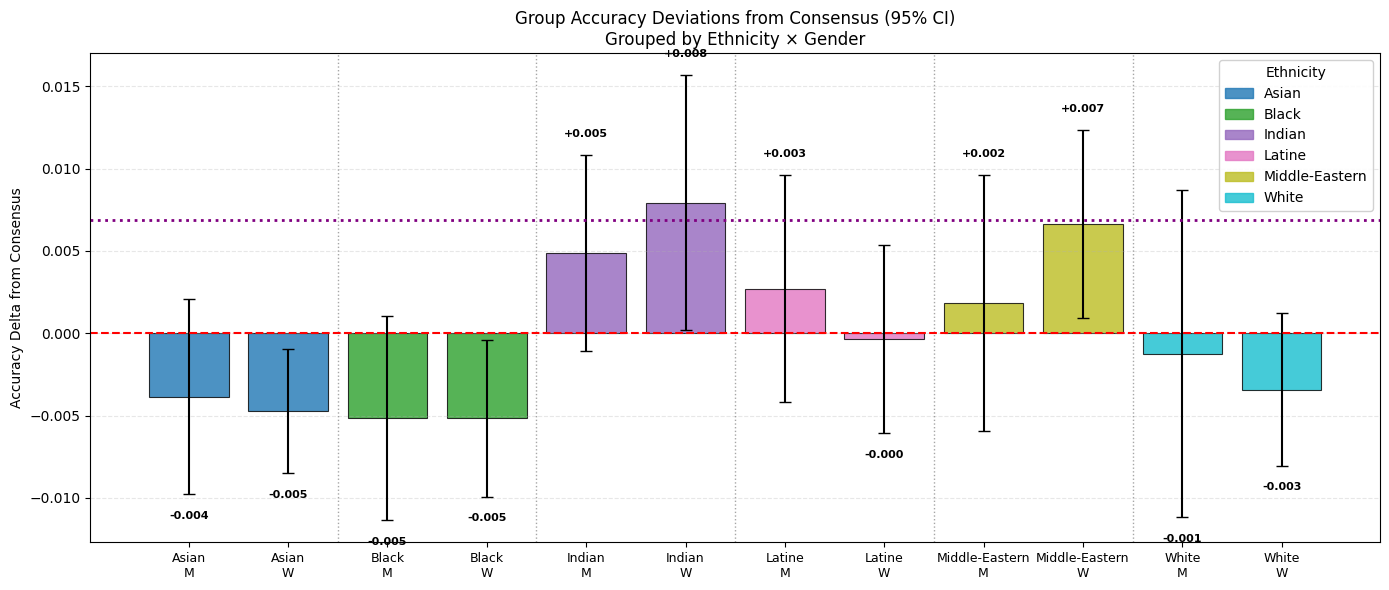


SUMMARY STATISTICS:
Combination         Mean Δ    95% CI         n    
--------------------------------------------------
asian_man           -0.004    [-0.010, +0.002]5    
asian_woman         -0.005    [-0.008, -0.001]5    
black_man           -0.005    [-0.011, +0.001]5    
black_woman         -0.005    [-0.010, -0.000]5    
indian_man          +0.005    [-0.001, +0.011]5    
indian_woman        +0.008    [+0.000, +0.016]5    
latine_man          +0.003    [-0.004, +0.010]5    
latine_woman        -0.000    [-0.006, +0.005]5    
middle_eastern_man  +0.002    [-0.006, +0.010]5    
middle_eastern_woman+0.007    [+0.001, +0.012]5    
white_man           -0.001    [-0.011, +0.009]5    
white_woman         -0.003    [-0.008, +0.001]5    
Plot generated successfully


=== ANALYSIS SUMMARY ===
Dataset: stereotype
Category columns analyzed: ['stereotype_type']
Missing category columns: []
Total profiles: 60
Group keys used: ('gender', 'ethnicity', 'age')


In [111]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS, PERSON_SYSTEMATIC
from cases import stereotypes_case, manipulation_case

results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, case=stereotypes_case, df=sample_mgsd, person_set=PERSON_SYSTEMATIC)

In [ ]:
from profiles.profile_sets import PERSON_ETHNICS

#print(PROFILE_META_ETHNICS)
#print(PERSON_ETHNICS)

{'profile1': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile2': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile3': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_3: 35>), 'profile4': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_4: 45>), 'profile5': PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_5: 55>), 'profile6': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>), 'profile7': PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_2: 25>), 'profile8': PersonMeta(gender=<Gender.woman: 'woman'>, ethni

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.726000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.713000  0.006275
woman      30  0.713267  0.006378

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7092  0.003795
black              10  0.7084  0.004195
indian             10  0.7190  0.005437
latine             10  0.7142  0.005029
middle_eastern     10  0.7170  0.005676
white              10  0.7110  0.005981

AGE:
     count      mean       std
age   

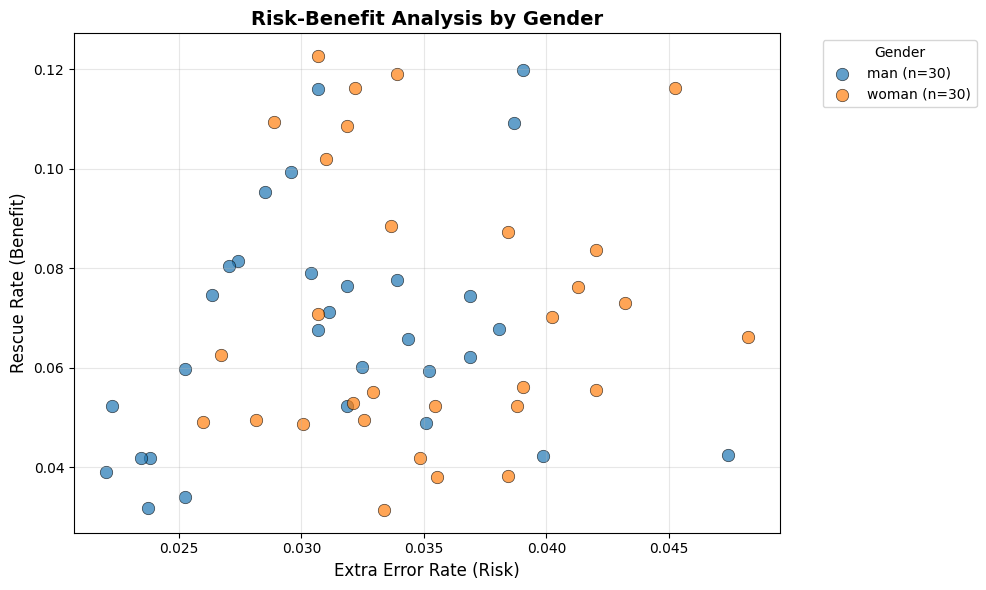


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


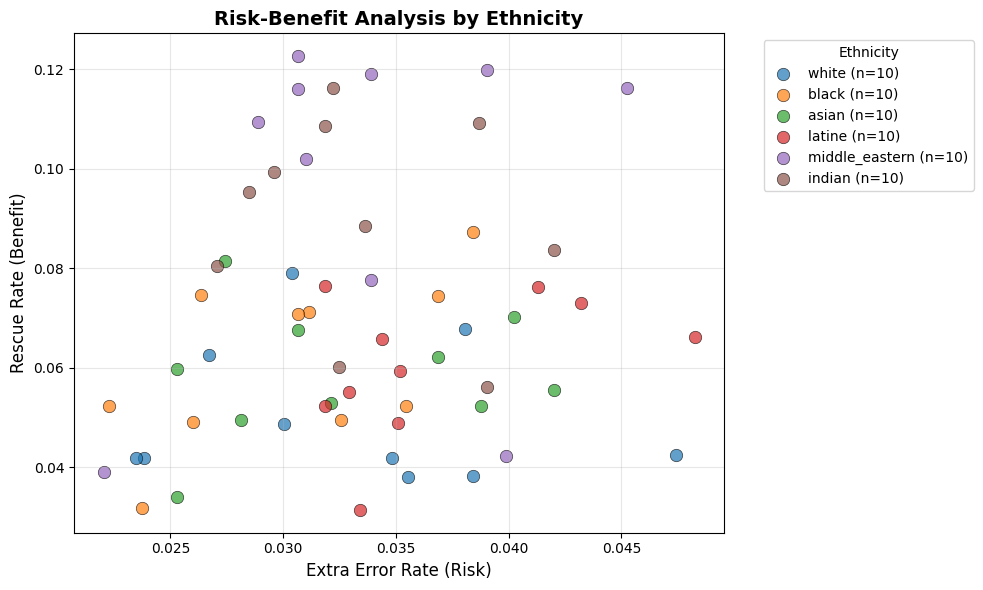


Creating risk-benefit plot for age...
  age levels: ['20', '55', '25', '35', '45']


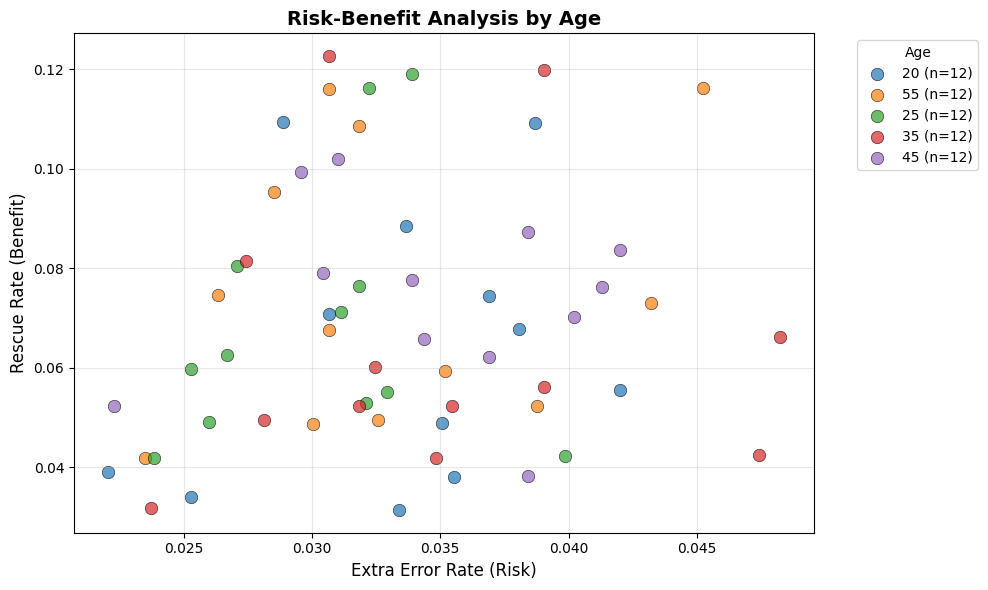


Creating Pareto frontier analysis...


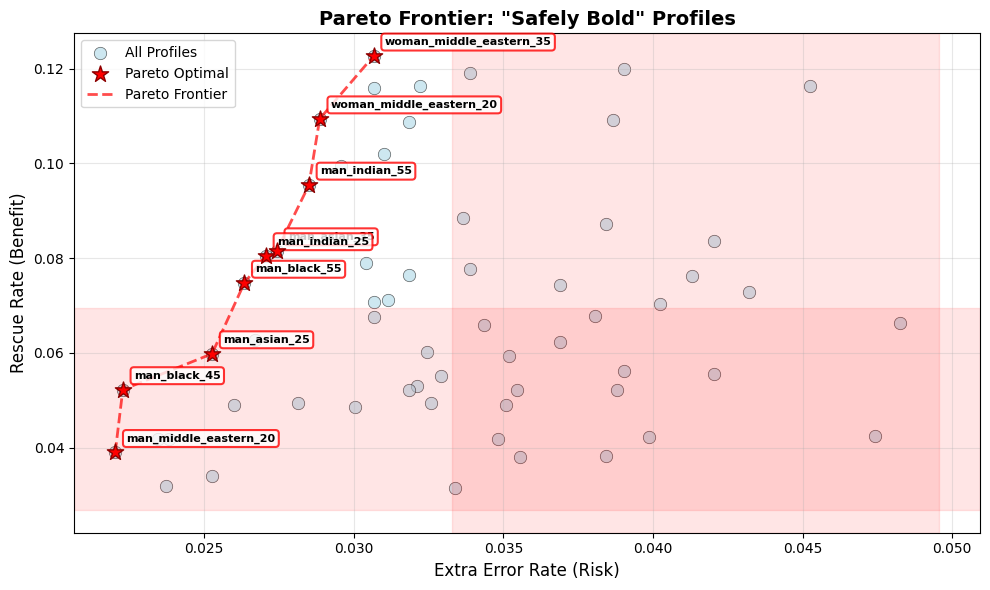


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (9 found):
  man_black_45 (profile14)
    Rescue Rate: 0.052, Extra Error Rate: 0.022
    Total Rescued: 10, Total Extra Errors: 14
  man_black_55 (profile15)
    Rescue Rate: 0.075, Extra Error Rate: 0.026
    Total Rescued: 10, Total Extra Errors: 14
  man_asian_25 (profile22)
    Rescue Rate: 0.060, Extra Error Rate: 0.025
    Total Rescued: 11, Total Extra Errors: 13
  man_asian_35 (profile23)
    Rescue Rate: 0.082, Extra Error Rate: 0.027
    Total Rescued: 10, Total Extra Errors: 14
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.039, Extra Error Rate: 0.022
    Total Rescued: 9, Total Extra Errors: 11
  woman_middle_eastern_20 (profile46)
    Rescue Rate: 0.109, Extra Error Rate: 0.029
    Total Rescued: 17, Total Extra Errors: 15
  woman_middle_eastern_35 (profile48)
    Rescue Rate: 0.123, Extra Error Rate: 0.031
    Total Rescued: 18, Total Extra Errors: 16
  man_indian_25 (profile52)
    Rescue Rate: 0.081, E

In [92]:
from analysis_1 import run_full_tier1_analysis

# "cognitive_style"
# "age"
#result_tier1 = run_full_tier1_analysis(merged_df,  group_keys=("gender", "ethnicity", "cognitive_style"),  person_set=PERSON_SYSTEMATIC)
result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case,  group_keys=("gender", "ethnicity", "age"),  person_set=PERSON_ETHNICS)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)
Category columns from CaseConfig: ['stereotype_type']

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7200

Ensemble Performance by Trait Group:
--------------------------------------------------
man_white                  

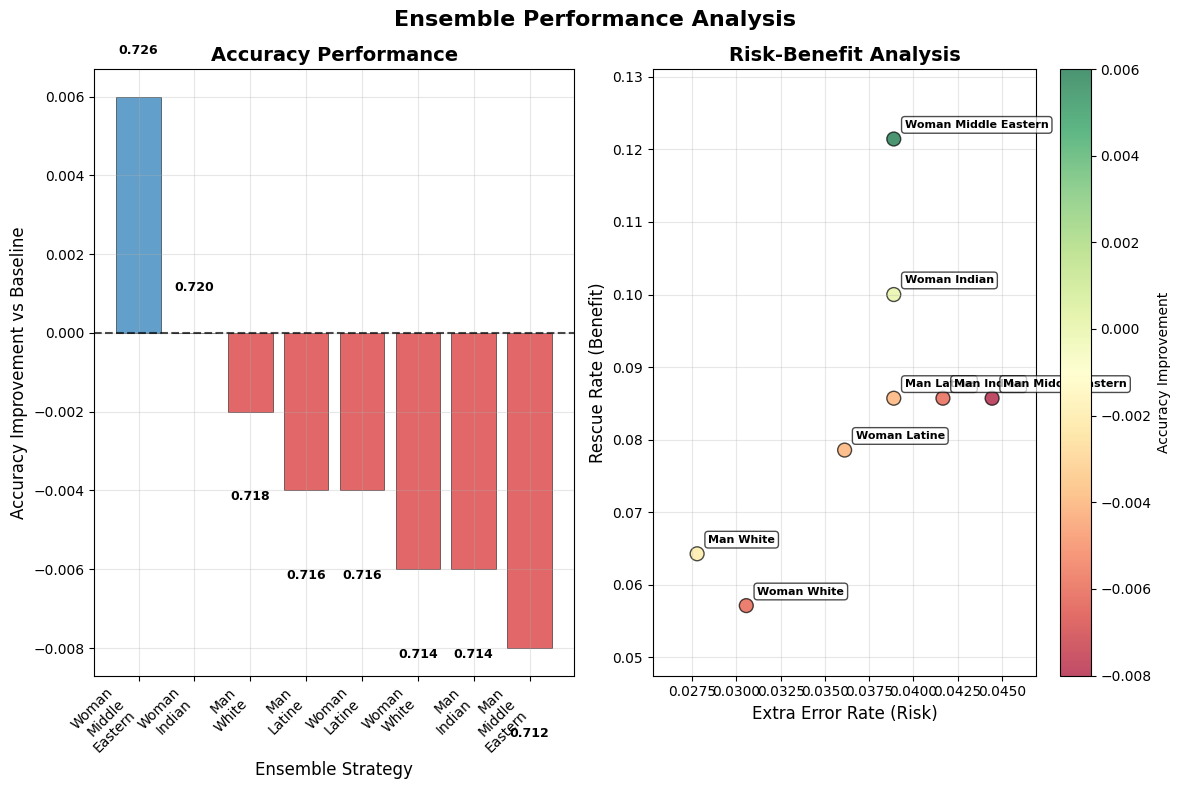

2. Cluster Analysis...
   Error creating cluster plot: 'cluster_analysis'
4. System-Level Recommendations...


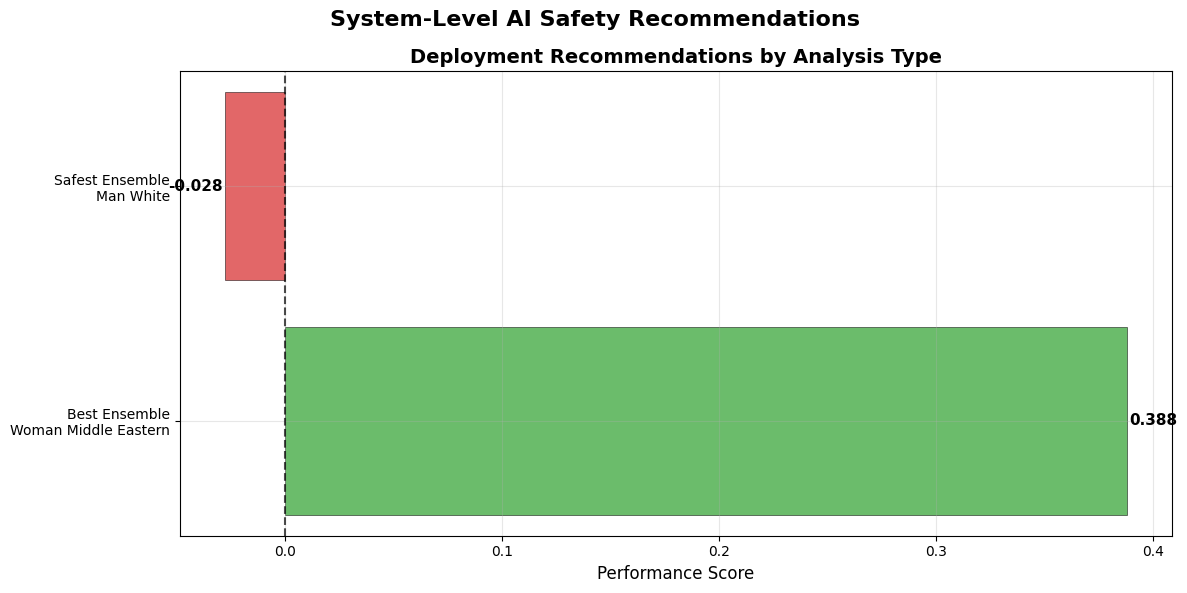


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_middle_eastern
   • Cognitive style analysis skipped: No cognitive style data found


In [48]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

results_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    person_set=PERSON_ETHNICS,
    case=stereotypes_case,
    group_keys=("gender", "ethnicity"))

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC, group_keys=("gender", "ethnicity", "cognitive_style"))


In [49]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS)

EXECUTING TIER 3 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
ERROR in consistency analysis: consistency_vs_boldness_analysis() missing 1 required positional argument: 'case'

=== Running Simplified Causal Modeling ===
ERROR in causal modeling: simplified_causal_modeling() missing 1 required positional argument: 'case'

=== Creating Consistency Analysis Visualizations ===

=== Creating Causal Model Visualizations ===

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Insufficient data for consistency-boldness analysis

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Insufficient
   - Bias Detection Capability: Limited
   - Generalizability: Domain-specific
   - Profile coverage: 0 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


## Analysis of Few-shots role playing

In [65]:
from analysis_tools import (
    load_and_merge_profiles
    )
from cases import stereotypes_case
merged_df = load_and_merge_profiles(
    base_file_path="results/openai_4.1_mini/few_shot/classic/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    #role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_system/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    role_playing_glob_pattern="results/openai_4.1_mini/few_shot/role_playing_ethnics/*/results_stereotype_few_shot_prompt_short_3examples_binary.csv",
    sample_df=sample_mgsd,
    case=stereotypes_case,
)

=== Found 60 profile result files.
=== Merged DataFrame ready with columns:
 ['sample_id', 'true_label', 'base_pred', 'stereotype_type', 'profile1', 'profile2', 'profile3', 'profile4', 'profile5', 'profile6', 'profile7', 'profile8', 'profile9', 'profile10', 'profile11', 'profile12', 'profile13', 'profile14', 'profile15', 'profile16', 'profile17', 'profile18', 'profile19', 'profile20', 'profile21', 'profile22', 'profile23', 'profile24', 'profile25', 'profile26', 'profile27', 'profile28', 'profile29', 'profile30', 'profile31', 'profile32', 'profile33', 'profile34', 'profile35', 'profile36', 'profile37', 'profile38', 'profile39', 'profile40', 'profile41', 'profile42', 'profile43', 'profile44', 'profile45', 'profile46', 'profile47', 'profile48', 'profile49', 'profile50', 'profile51', 'profile52', 'profile53', 'profile54', 'profile55', 'profile56', 'profile57', 'profile58', 'profile59', 'profile60']


Using group keys: ('gender', 'ethnicity', 'age')


=== DEMOGRAPHIC ACCURACY DIFFERENCES ===
[INFO] Profiles covered by metadata: 60/60

COMPREHENSIVE DEMOGRAPHIC ACCURACY DIFFERENCES ANALYSIS

EXECUTIVE SUMMARY
----------------------------------------
Total Comparisons Performed: 32
Significant Differences Found: 6
Statistical Significance Rate: 18.8%

LARGEST EFFECT SIZES
----------------------------------------
 1. black_vs_indian                     Effect Size: -3.180 (Large)
 2. indian_vs_latine                    Effect Size:  2.567 (Large)
 3. indian_vs_white                     Effect Size:  1.903 (Large)
 4. asian_vs_indian                     Effect Size: -1.859 (Large)
 5. black_vs_middle_eastern             Effect Size: -1.395 (Large)

DETAILED SIGNIFICANT RESULTS
[NON-SIGNIFICANT]     men_vs_women                        | Man: 0.716 | Woman: 0.714
         Δ = +0.003 | p = 0.161 | d = 0.373
[SIGNIFICANT] asian_vs_black                      | Asian: 0.715 | Black: 0.709
   

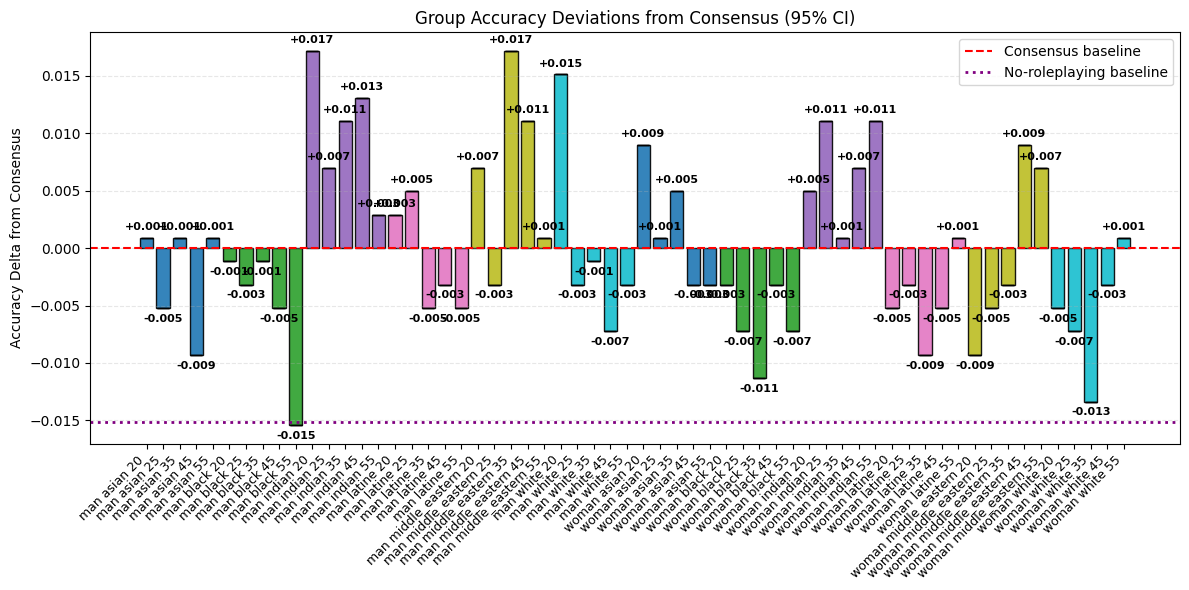

Plot generated successfully


In [66]:
from analysis_0 import *
from profiles.profile_sets import PERSON_ETHNICS

results_preliminary = run_full_preliminary_analysis(merged_df, case=stereotypes_case,
                                                     df = sample_mgsd, person_set=PERSON_ETHNICS)
#results = run_full_preliminary_analysis(merged_df, df = sample_mgsd, person_set=PERSON_SYSTEMATIC)

COMPREHENSIVE TIER 1 BIAS ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Dataset shape: (500, 64)

STEP 1: FACTORIAL N-WAY ANOVA ANALYSIS
=== FACTORIAL ANOVA ANALYSIS ===
Group keys: ('gender', 'ethnicity', 'age')
Found 60 profile columns

Performance data shape: (60, 5)
Traits found: ['gender', 'ethnicity', 'age']

=== DATA VALIDATION ===
Accuracy range: 0.700000 - 0.732000
Missing values in accuracy: 0
Infinite values in accuracy: 0

=== SUMMARY STATISTICS ===
GENDER:
        count      mean       std
gender                           
man        30  0.716467  0.007873
woman      30  0.713800  0.006630

ETHNICITY:
                count    mean       std
ethnicity                              
asian              10  0.7148  0.005095
black              10  0.7094  0.004526
indian             10  0.7236  0.004881
latine             10  0.7124  0.004300
middle_eastern     10  0.7182  0.008244
white              10  0.7124  0.007291

AGE:
     count      mean       std
age   

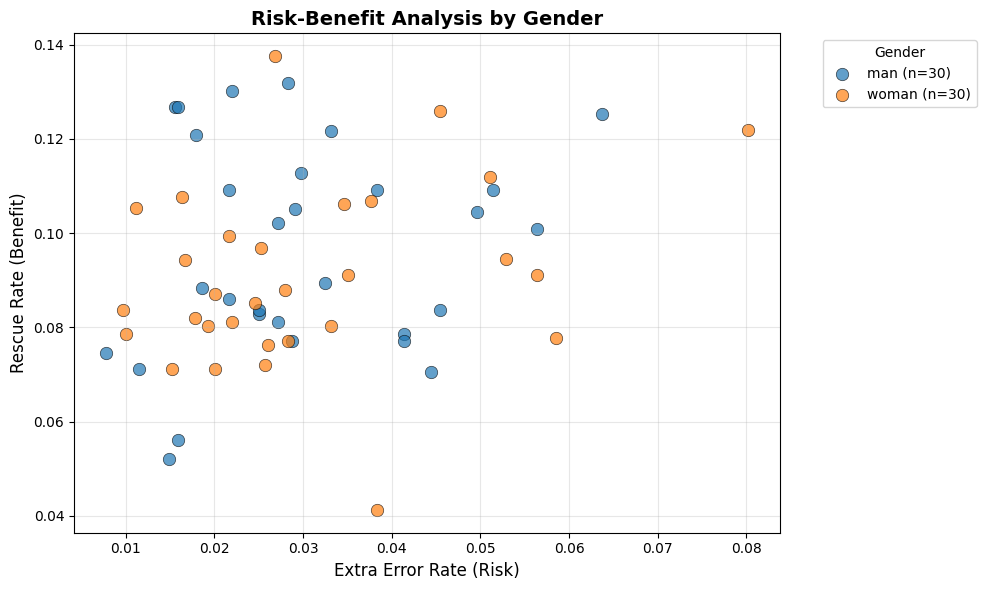


Creating risk-benefit plot for ethnicity...
  ethnicity levels: ['white', 'black', 'asian', 'latine', 'middle_eastern', 'indian']


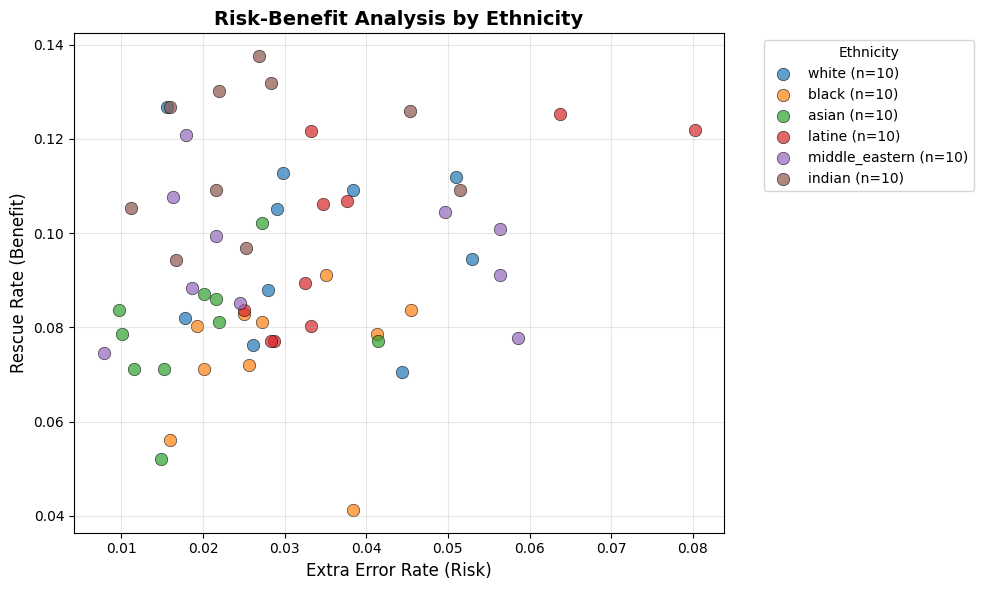


Creating risk-benefit plot for age...
  age levels: ['20', '55', '25', '35', '45']


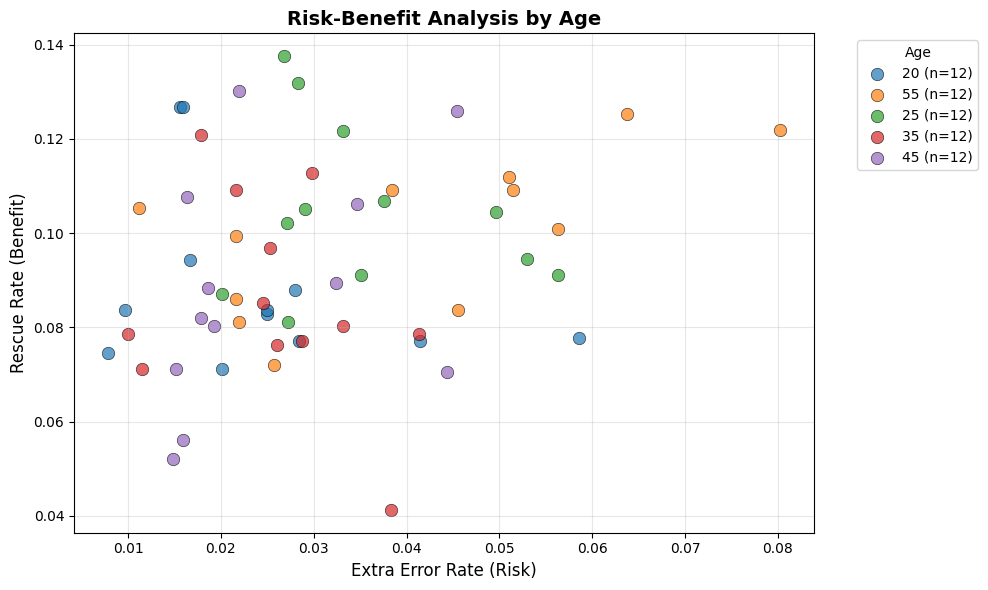


Creating Pareto frontier analysis...


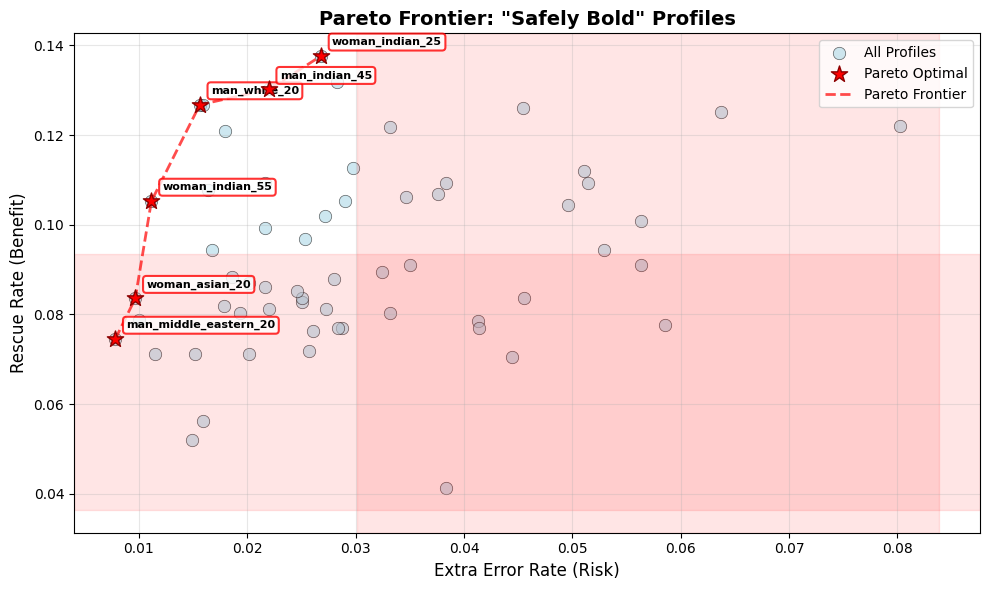


PARETO FRONTIER ANALYSIS RESULTS

Pareto Optimal Profiles (6 found):
  man_white_20 (profile1)
    Rescue Rate: 0.127, Extra Error Rate: 0.016
    Total Rescued: 25, Total Extra Errors: 10
  woman_asian_20 (profile26)
    Rescue Rate: 0.084, Extra Error Rate: 0.010
    Total Rescued: 18, Total Extra Errors: 6
  man_middle_eastern_20 (profile41)
    Rescue Rate: 0.074, Extra Error Rate: 0.008
    Total Rescued: 16, Total Extra Errors: 5
  man_indian_45 (profile54)
    Rescue Rate: 0.130, Extra Error Rate: 0.022
    Total Rescued: 24, Total Extra Errors: 10
  woman_indian_25 (profile57)
    Rescue Rate: 0.138, Extra Error Rate: 0.027
    Total Rescued: 26, Total Extra Errors: 13
  woman_indian_55 (profile60)
    Rescue Rate: 0.105, Extra Error Rate: 0.011
    Total Rescued: 20, Total Extra Errors: 7

Risk-Benefit Statistics:
  Total profiles analyzed: 60
  Average rescue rate: 0.094
  Average extra error rate: 0.030
  Best rescue rate: 0.138
  Lowest extra error rate: 0.008

Profile Arc

In [67]:
from analysis_1 import run_full_tier1_analysis

result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, group_keys=("gender", "ethnicity", "age"), person_set=PERSON_ETHNICS)
#result_tier1 = run_full_tier1_analysis(merged_df, case=stereotypes_case, group_keys=("gender", "ethnicity", "cognitive_style"), person_set=PERSON_SYSTEMATIC)

EXECUTING COMPREHENSIVE TIER 2 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity')
Dataset shape: (500, 64)
Category columns from CaseConfig: ['stereotype_type']

=== Running Step 1: Ensemble by Trait Analysis...
ENSEMBLE BY TRAIT ANALYSIS - PERSONSET VERSION
Group keys: ('gender', 'ethnicity')
Building trait groups with keys: ('gender', 'ethnicity')
Found 60 profile columns
Discovered trait values:
  gender: ['man', 'woman']
  ethnicity: ['asian', 'black', 'indian', 'latine', 'middle_eastern', 'white']
Created 12 trait groups:
  man_asian: 5 profiles
  man_black: 5 profiles
  man_indian: 5 profiles
  man_latine: 5 profiles
  man_middle_eastern: 5 profiles
  man_white: 5 profiles
  woman_asian: 5 profiles
  woman_black: 5 profiles
  woman_indian: 5 profiles
  woman_latine: 5 profiles
  woman_middle_eastern: 5 profiles
  woman_white: 5 profiles
Baseline accuracy: 0.7000

Ensemble Performance by Trait Group:
--------------------------------------------------
man_white                  

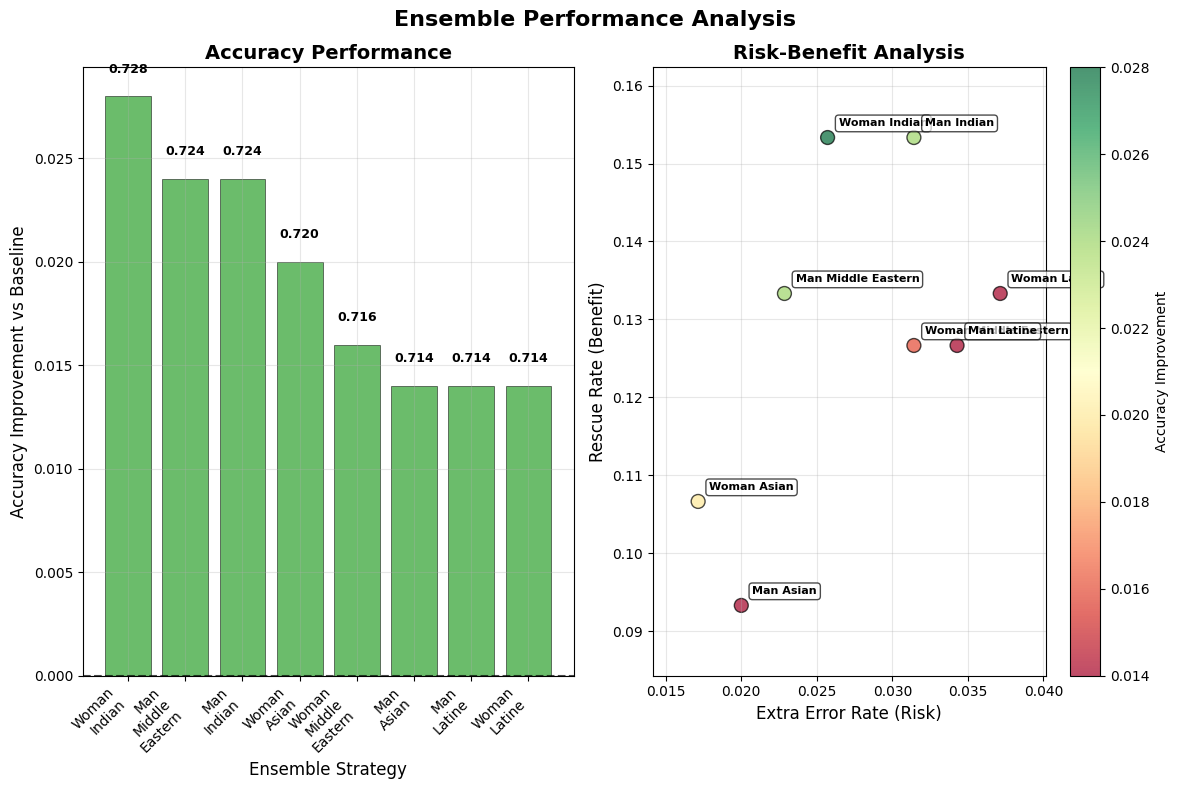

2. Cluster Analysis...
   Error creating cluster plot: 'cluster_analysis'
4. System-Level Recommendations...


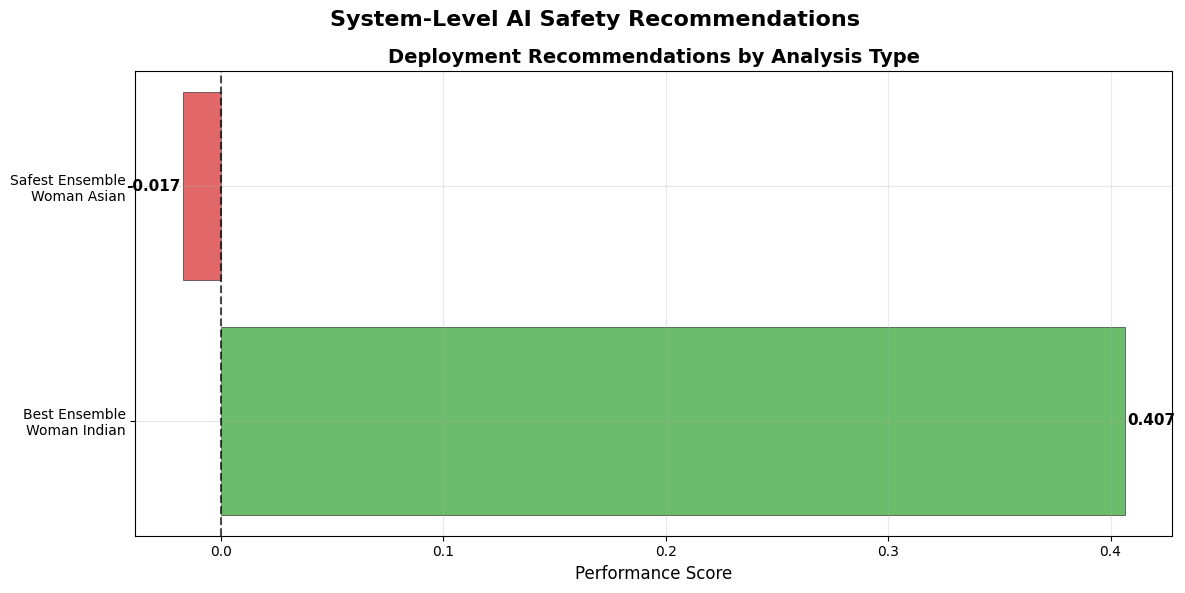


Completed! Created 2 visualizations.
SUCCESS: Visualizations created successfully

COMPREHENSIVE TIER 2 EXECUTIVE SUMMARY
   • Best Overall Ensemble: woman_indian
   • Cognitive style analysis skipped: No cognitive style data found


In [68]:
from analysis_2 import run_full_tier2_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier2 = run_full_tier2_analysis(
    merged_df=merged_df,
    case=stereotypes_case,
    person_set=PERSON_ETHNICS,
    group_keys=("gender", "ethnicity"))

#result_tier2 = run_full_tier2_analysis(merged_df, person_set=PERSON_SYSTEMATIC)

EXECUTING TIER 3 ANALYSIS PIPELINE
Group keys: ('gender', 'ethnicity', 'age')
Cross-validation folds: 5

=== Running Consistency vs Boldness Analysis ===
CONSISTENCY vs BOLDNESS TRADEOFF ANALYSIS
Group keys for analysis: ('gender', 'ethnicity', 'age')
Found 60 valid profiles out of 60 total profile columns
=== Calculating consistency across 5 folds...
=== Calculating boldness metrics...
Creating simplified boldness metrics...
=== Analyzing consistency-boldness correlations by demographics...
Analysis dataset shape: (60, 11)

--- OVERALL CORRELATION RESULTS:
  Volatility vs Boldness: r=0.093, p=0.4779 
    → Positive correlation means less consistent profiles are bolder
  Consistency vs Boldness: r=-0.093, p=0.4817 
    → Negative correlation means more consistent profiles are less bold
  Volatility vs Rescue Rate: r=0.063, p=0.6314 
  Boldness vs Accuracy: r=0.547, p=0.0000 ***

--- CORRELATIONS BY GENDER:
  man (n=30): Volatility vs Boldness r=0.030, p=0.8746 
  woman (n=30): Volatili

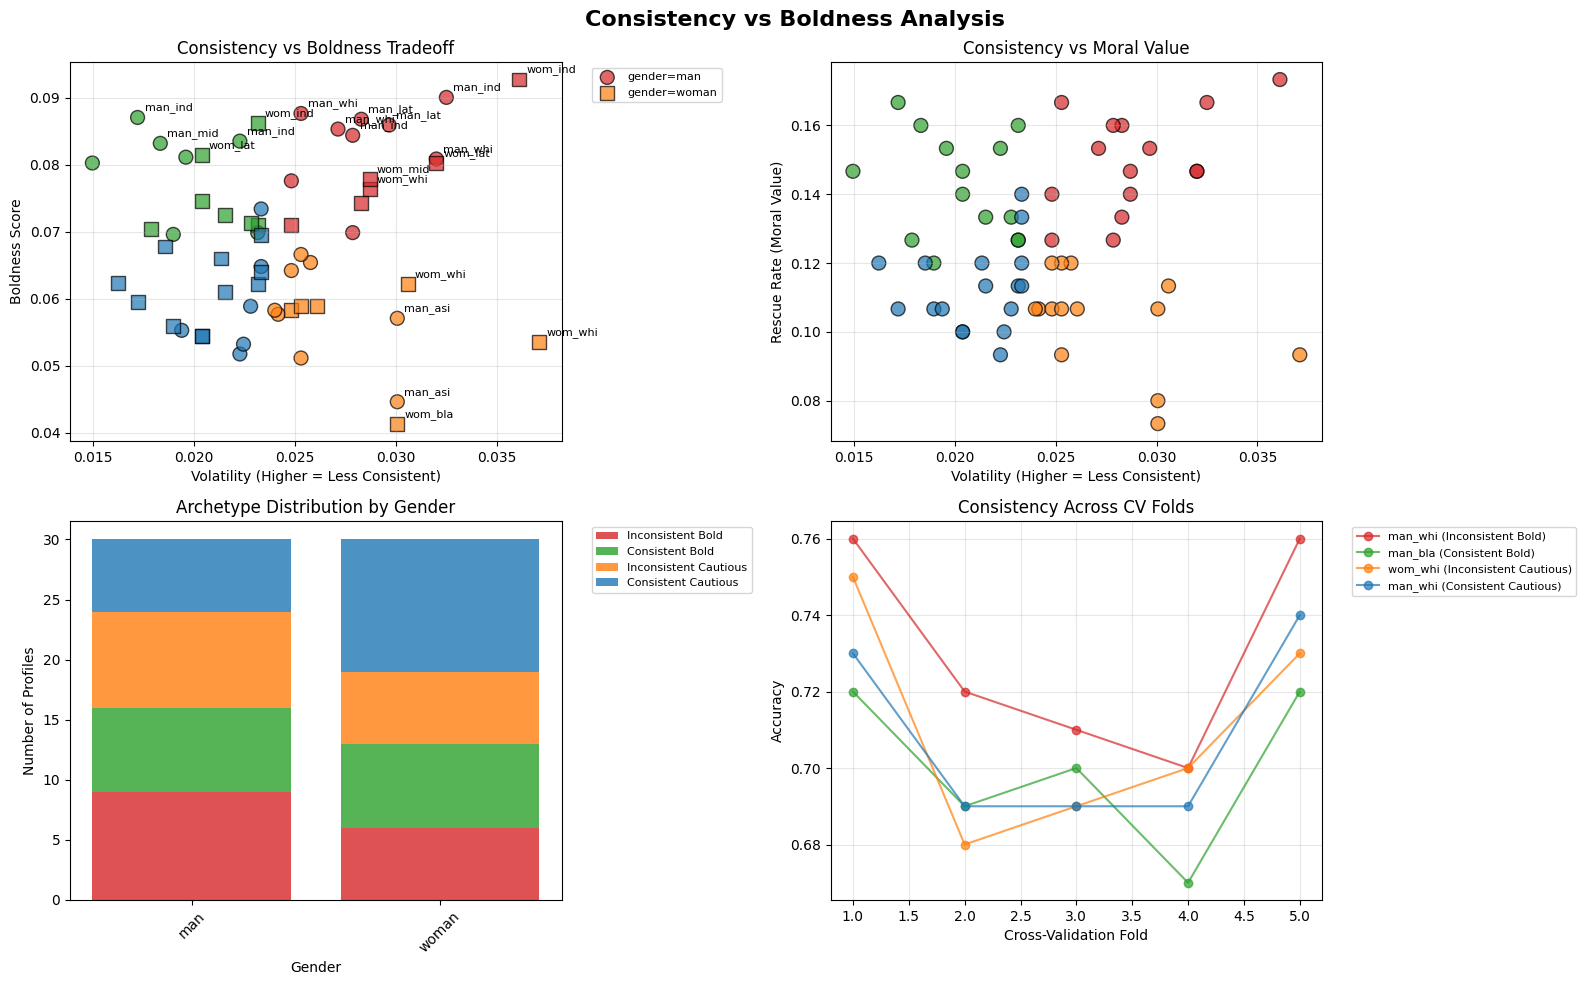

Consistency visualizations created successfully

=== Creating Causal Model Visualizations ===


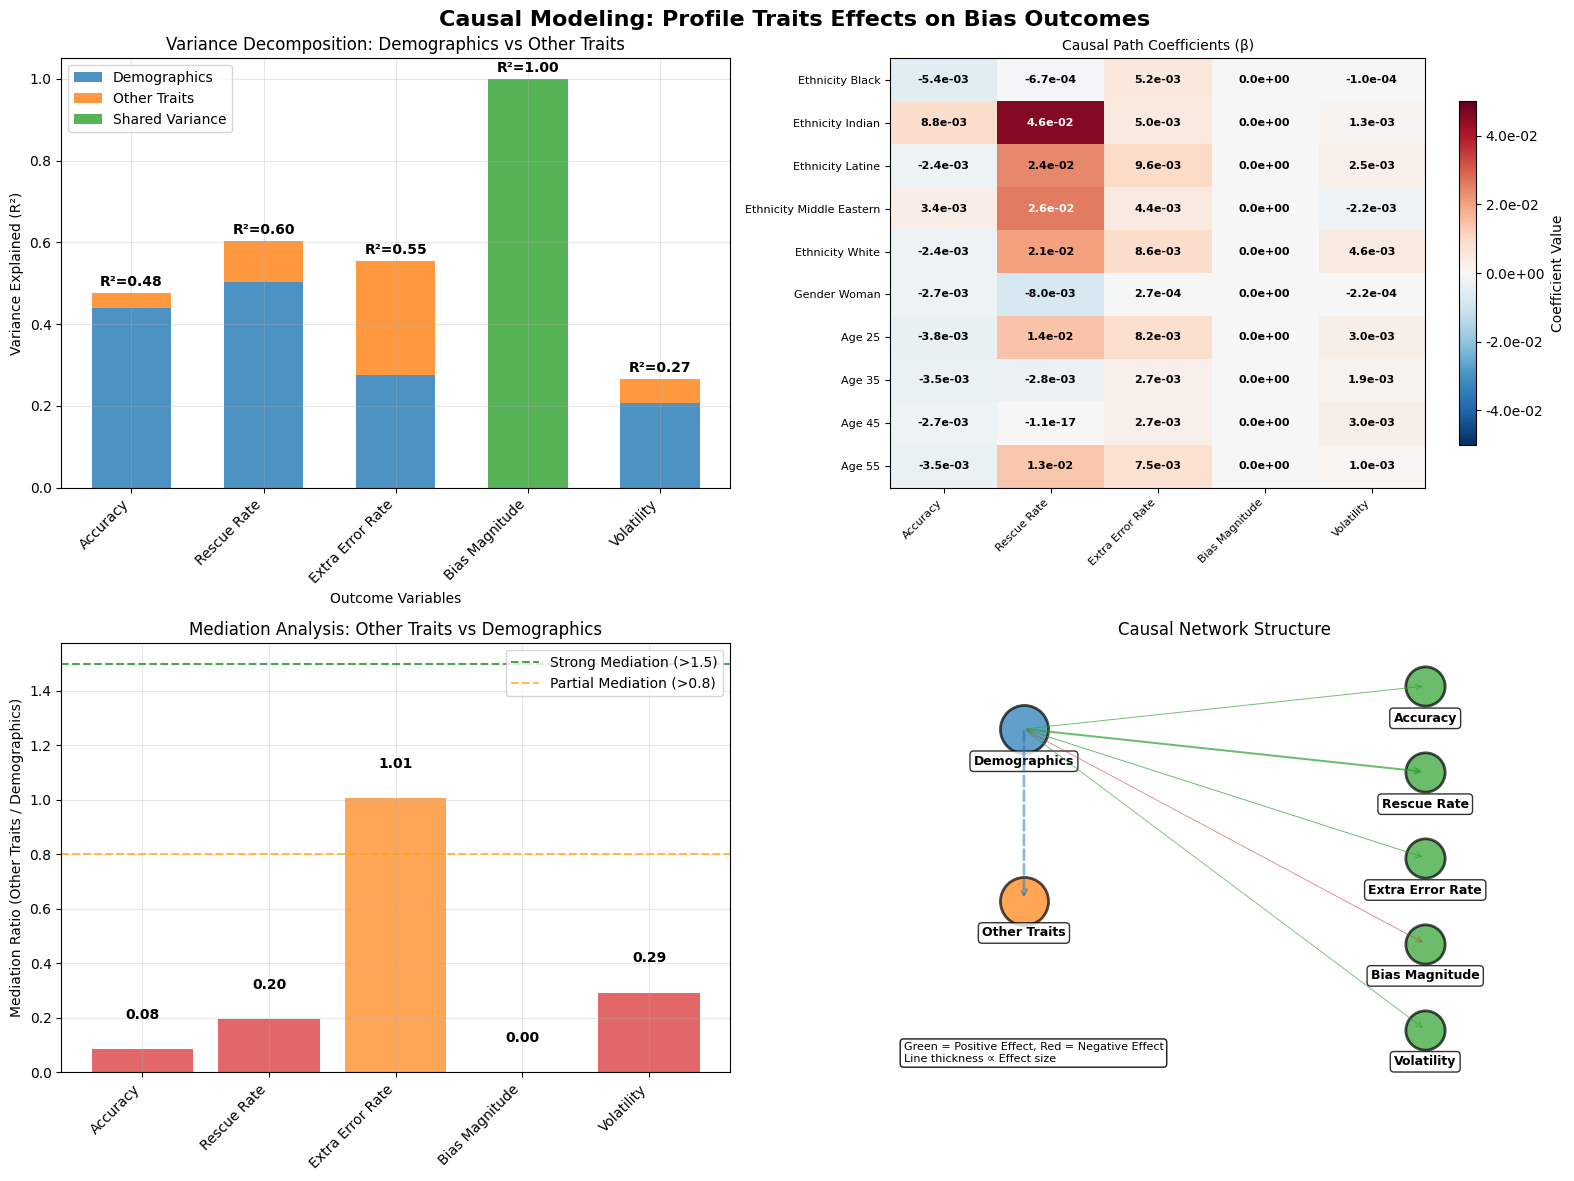

Causal visualizations created successfully

TIER 3 THEORETICAL INTEGRATION

=== THEORETICAL INSIGHTS:
   - Consistent profiles match or outperform inconsistent ones in moral value
   - Implication: Consistency should be prioritized over boldness in AI systems
   - Evidence: Inconsistent rescue rate: 0.127 vs Consistent: 0.126
   - Strongest predictor of moral value (rescue): ethnicity_indian
   - Strongest predictor of performance (accuracy): ethnicity_indian
   - WARNING: Demographic traits strongly influence key outcomes
   - Bias assessment: 3 high, 0 moderate bias cases detected

THESIS-LEVEL CONCLUSIONS

METHODOLOGICAL ASSESSMENT
   - Data Quality: Good
   - Statistical Power: Adequate
   - Bias Detection Capability: Strong
   - Generalizability: Domain-specific
   - Profile coverage: 60 profiles
   - Trait coverage: 3 (gender, ethnicity, age)


In [69]:
from analysis_3 import run_full_tier3_analysis
from profiles.profile_sets import PERSON_SYSTEMATIC, PERSON_ETHNICS

result_tier3 = run_full_tier3_analysis(merged_df, person_set=PERSON_ETHNICS, case=stereotypes_case)

In [24]:
from MoP_enhanced import create_autonomous_mop
import pandas as pd
import numpy as np

def run_autonomous_enhanced_mop(merged_df, 
                               person_set,
                               result_tier1=None,
                               result_tier2=None, 
                               result_tier3=None,
                               result_preliminary=None):
    """
    Run the autonomous enhanced MoP with proper error handling and debugging.
    """
    
    print("=" * 80)
    print("AUTONOMOUS ENHANCED MOP EXECUTION")
    print("=" * 80)
    
    # Debug: Check label distribution
    print("=== DEBUGGING LABEL DETECTION ===")
    unique_labels = merged_df['true_label'].unique()
    label_counts = merged_df['true_label'].value_counts()
    print(f"Unique labels found: {unique_labels}")
    print(f"Label distribution: {dict(label_counts)}")
    
    # Manual label verification for your data
    if len(unique_labels) != 2:
        print(f"⚠ WARNING: Expected 2 labels, found {len(unique_labels)}")
        print("Please check your true_label column")
        return None
    
    # Create autonomous MoP
    print("\n=== CREATING AUTONOMOUS MOP ===")
    mop = create_autonomous_mop(person_set)
    
    # Test trait extraction for first few profiles
    print("\n=== TESTING TRAIT EXTRACTION ===")
    test_profiles = ['profile1_passive', 'profile26_passive', 'profile54_passive']
    for profile in test_profiles:
        if profile in merged_df.columns:
            ethnicity = mop._get_profile_ethnicity(profile)
            gender = mop._get_profile_gender(profile)
            print(f"{profile}: ethnicity={ethnicity}, gender={gender}")
    
    # Fit the model
    print("\n=== FITTING AUTONOMOUS MOP ===")
    try:
        mop.fit(
            merged_df,
            result_tier1=result_tier1,
            result_tier2=result_tier2,
            result_tier3=result_tier3,
            result_preliminary=result_preliminary
        )
        
        print("✓ Model fitted successfully")
        
        # Debug: Check detected labels
        print(f"Auto-detected positive label: '{mop.positive_label_}'")
        print(f"Auto-detected negative label: '{mop.negative_label_}'")
        
        if mop.positive_label_ == mop.negative_label_:
            print("❌ ERROR: Positive and negative labels are the same!")
            print("This will cause prediction issues.")
            
            # Manual fix for your data
            if 'stereotype' in unique_labels and 'unrelated' in unique_labels:
                print("Manually setting labels: stereotype=positive, unrelated=negative")
                mop.positive_label_ = 'stereotype' 
                mop.negative_label_ = 'unrelated'
            else:
                print("Please manually set the correct positive/negative labels")
                return None
        
        # Generate predictions with threshold tuning
        print("\n=== GENERATING PREDICTIONS ===")
        predictions, best_threshold = mop.predict_with_tuning(merged_df)
        
        # Evaluate performance
        print("\n=== EVALUATING PERFORMANCE ===")
        results = mop.evaluate(predictions, merged_df['true_label'], merged_df['base_pred'])
        
        print(f"\nPERFORMANCE RESULTS:")
        print(f"  Best threshold: {best_threshold:.3f}")
        print(f"  Accuracy: {results['accuracy']:.4f}")
        if 'accuracy_improvement' in results:
            print(f"  Improvement over baseline: {results['accuracy_improvement']:+.4f}")
        if 'rescue_rate' in results:
            print(f"  Rescue rate: {results['rescue_rate']:.4f}")
        if 'extra_error_rate' in results:
            print(f"  Extra error rate: {results['extra_error_rate']:.4f}")
        
        # Compare with individuals
        print("\n=== COMPARING WITH INDIVIDUAL PROFILES ===")
        top_profiles = ['profile54_passive', 'profile57_passive', 'profile1_passive']
        individual_results = {}
        
        for profile in top_profiles:
            if profile in merged_df.columns:
                individual_preds = merged_df[profile]
                individual_eval = mop.evaluate(individual_preds, merged_df['true_label'], merged_df['base_pred'])
                individual_results[profile] = individual_eval['accuracy']
                print(f"{profile}: {individual_eval['accuracy']:.4f}")
        
        ensemble_accuracy = results['accuracy']
        print(f"Autonomous Ensemble: {ensemble_accuracy:.4f}")
        
        if individual_results:
            best_individual = max(individual_results.values())
            improvement = ensemble_accuracy - best_individual
            print(f"Ensemble vs Best Individual: {improvement:+.4f}")
            
            if improvement > 0:
                print("✅ SUCCESS: Autonomous ensemble beats individual profiles!")
            else:
                print("⚠️ Ensemble underperforms - may need constraint adjustment")
        
        # Get detailed summary
        print("\n=== AUTONOMOUS CONFIGURATION SUMMARY ===")
        summary = mop.get_autonomous_summary()
        autonomous_details = summary.get('autonomous_details', {})
        
        print(f"Auto-configured: {autonomous_details.get('auto_configured', False)}")
        print(f"Learned Pareto pool: {autonomous_details.get('learned_pareto_pool_size', 0)} profiles")
        print(f"Learned performance map: {len(autonomous_details.get('learned_performance_map', {}))}")
        print(f"Learned constraints: {autonomous_details.get('learned_constraints', {})}")
        
        # Print selected ensemble composition
        if 'all' in summary.get('per_category', {}):
            category_data = summary['per_category']['all']
            print(f"\nFinal Ensemble Composition:")
            for profile_info in category_data.get('profiles', []):
                profile = profile_info.get('profile', 'unknown')
                weight = profile_info.get('weight', 0.0)
                ethnicity = profile_info.get('ethnicity', 'unknown')
                gender = profile_info.get('gender', 'unknown')
                if weight > 0.01:
                    print(f"  {profile}: {weight:.3f} ({gender} {ethnicity})")
        
        return {
            'mop': mop,
            'predictions': predictions,
            'best_threshold': best_threshold,
            'results': results,
            'individual_comparison': individual_results,
            'summary': summary
        }
        
    except Exception as e:
        print(f"❌ ERROR during fitting: {e}")
        import traceback
        traceback.print_exc()
        return None


def debug_profile_traits(person_set, profiles_to_check=None):
    """Debug function to check trait extraction."""
    if profiles_to_check is None:
        profiles_to_check = ['profile1_passive', 'profile26_passive', 'profile54_passive', 'profile57_passive']
    
    print("=== DEBUGGING TRAIT EXTRACTION ===")
    
    for profile in profiles_to_check:
        # Test the correct extraction method
        pid = profile.replace('_passive', '').replace('_active', '')  # profile1_passive -> profile1
        
        print(f"\nProfile: {profile}")
        print(f"  Extracted PID: '{pid}'")
        print(f"  PID in metadata: {pid in person_set.metadata}")
        
        # Show what's actually in metadata (first few keys)
        metadata_keys = list(person_set.metadata.keys())[:5]
        print(f"  Sample metadata keys: {metadata_keys}")
        
        # Try trait extraction
        try:
            traits = person_set.get_traits(pid, ('gender', 'ethnicity', 'age'))
            print(f"  Extracted traits: {traits}")
        except Exception as e:
            print(f"  Extraction error: {e}")
        
        # Try direct metadata access
        if pid in person_set.metadata:
            meta = person_set.metadata[pid]
            print(f"  Direct metadata: {meta}")
            print(f"  Gender: {meta.gender.value}")
            print(f"  Ethnicity: {meta.ethnicity.value}")
            print(f"  Age: {meta.age.value}")
        else:
            print(f"  PID '{pid}' not found in metadata")


# Debug trait extraction first
debug_profile_traits(PERSON_ETHNICS)

# Run autonomous MoP
results = run_autonomous_enhanced_mop(
    merged_df, 
    PERSON_ETHNICS,
    result_tier1=result_tier1,
    result_tier2=result_tier2, 
    result_tier3=result_tier3,
    result_preliminary=results_preliminary
)

if results:
    print("\\n🎉 Autonomous Enhanced MoP completed successfully!")
    print(f"Final accuracy: {results['results']['accuracy']:.4f}")
    print(f"Best threshold: {results['best_threshold']:.3f}")
else:
    print("❌ Autonomous Enhanced MoP failed")

=== DEBUGGING TRAIT EXTRACTION ===

Profile: profile1_passive
  Extracted PID: 'profile1'
  PID in metadata: True
  Sample metadata keys: ['profile1', 'profile2', 'profile3', 'profile4', 'profile5']
  Extracted traits: {'gender': 'man', 'ethnicity': 'white', 'age': 20}
  Direct metadata: PersonMeta(gender=<Gender.man: 'man'>, ethnicity=<Ethnicity.white: 'white'>, cognitive_style=None, age=<Age.age_1: 20>)
  Gender: man
  Ethnicity: white
  Age: 20

Profile: profile26_passive
  Extracted PID: 'profile26'
  PID in metadata: True
  Sample metadata keys: ['profile1', 'profile2', 'profile3', 'profile4', 'profile5']
  Extracted traits: {'gender': 'woman', 'ethnicity': 'asian', 'age': 20}
  Direct metadata: PersonMeta(gender=<Gender.woman: 'woman'>, ethnicity=<Ethnicity.asian: 'asian'>, cognitive_style=None, age=<Age.age_1: 20>)
  Gender: woman
  Ethnicity: asian
  Age: 20

Profile: profile54_passive
  Extracted PID: 'profile54'
  PID in metadata: True
  Sample metadata keys: ['profile1', 'pr

In [35]:
from MoP_categories import create_smart_routing_mop
import pandas as pd
import numpy as np
from cases import stereotypes_case

def run_smart_routing_mop(merged_df, 
                         person_set,
                         result_tier2=None,
                         result_preliminary=None,
                         case_config=None):
    """
    Run the Smart Routing MoP and compare with ensemble approaches.
    """
    
    print("=" * 80)
    print("SMART ROUTING MOP EXECUTION")
    print("=" * 80)
    
    # Create Smart Routing MoP
    print("=== CREATING SMART ROUTING MOP ===")
    routing_mop = create_smart_routing_mop(person_set, case_config=case_config)
    
    # Fit with tier results (auto-configures routing)
    print("\n=== FITTING SMART ROUTING MOP ===")
    try:
        routing_mop.fit(
            merged_df,
            result_tier2=result_tier2,
            result_preliminary=result_preliminary
        )
        
        print("✓ Smart Routing MoP fitted successfully")
        
    except Exception as e:
        print(f"ERROR during fitting: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # Generate predictions with smart routing
    print("\n=== GENERATING SMART ROUTING PREDICTIONS ===")
    try:
        routing_predictions = routing_mop.predict(merged_df)
        print("Smart routing predictions generated")
        
    except Exception as e:
        print(f"ERROR during prediction: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # Evaluate routing performance
    print("\n=== EVALUATING ROUTING PERFORMANCE ===")
    try:
        routing_evaluation = routing_mop.evaluate_routing(merged_df)
        
        # Extract key metrics
        routing_accuracy = routing_evaluation['routing_performance']['accuracy']
        routing_improvement = routing_evaluation['routing_performance'].get('accuracy_improvement', 0)
        routing_rescue = routing_evaluation['routing_performance'].get('rescue_rate', 0)
        
        print(f"\nSMART ROUTING RESULTS:")
        print(f"  Accuracy: {routing_accuracy:.4f}")
        print(f"  Improvement over baseline: {routing_improvement:+.4f}")
        print(f"  Rescue rate: {routing_rescue:.4f}")
        
    except Exception as e:
        print(f"ERROR during evaluation: {e}")
        routing_evaluation = None
    
    # Compare with individual experts
    print("\n=== COMPARING WITH INDIVIDUAL EXPERTS ===")
    if routing_evaluation and 'individual_comparison' in routing_evaluation:
        individual_results = routing_evaluation['individual_comparison']
        
        print("Individual Expert Performance:")
        for profile, accuracy in individual_results.items():
            # Get demographics
            ethnicity = routing_mop._get_profile_ethnicity(profile)
            gender = routing_mop._get_profile_gender(profile)
            print(f"  {profile}: {accuracy:.4f} ({gender} {ethnicity})")
        
        if individual_results:
            best_individual = max(individual_results.values())
            routing_vs_best = routing_accuracy - best_individual
            print(f"\nRouting vs Best Individual: {routing_vs_best:+.4f}")
            
            if routing_vs_best > 0:
                print("Conclusion: Smart Routing BEATS individual experts!")
            else:
                print("Conclusion: Individual expert outperforms routing")
    
    # Show discovered routing rules
    print("\n=== DISCOVERED ROUTING RULES ===")
    routing_summary = routing_mop.get_routing_summary()
    
    if 'routing_rules' in routing_summary:
        print("Category → Expert Mapping:")
        for category, rule in routing_summary['routing_rules'].items():
            expert = rule['expert_profile']
            demographics = rule['expert_demographics']
            accuracy = rule['expert_accuracy']
            confidence = rule['confidence']
            
            demo_str = f"{demographics.get('gender', '?')} {demographics.get('ethnicity', '?')}"
            print(f"  {category:<12} → {expert:<20} ({demo_str})")
            print(f"                      acc={accuracy:.3f}, confidence={confidence:.3f}")
    
    # Category-specific performance
    if routing_evaluation and 'category_performance' in routing_evaluation:
        print(f"\nCATEGORY-SPECIFIC PERFORMANCE:")
        cat_performance = routing_evaluation['category_performance']
        
        for category, accuracy in cat_performance.items():
            print(f"  {category}: {accuracy:.4f}")
    
    # Show fallback ensemble
    if 'fallback_ensemble' in routing_summary:
        fallback = routing_summary['fallback_ensemble']
        print(f"\nFallback Ensemble: {fallback['profiles']}")
    
    return {
        'routing_mop': routing_mop,
        'predictions': routing_predictions,
        'evaluation': routing_evaluation,
        'routing_summary': routing_summary
    }


def compare_routing_vs_ensemble(merged_df,
                               person_set,
                               result_tier1=None,
                               result_tier2=None,
                               result_tier3=None,
                               result_preliminary=None,
                               case_config=None):
    """
    Direct comparison between Smart Routing and Autonomous Ensemble approaches.
    """
    
    print("=" * 80)
    print("ROUTING vs ENSEMBLE COMPARISON")
    print("=" * 80)
    
    results = {}
    
    # Test Smart Routing MoP
    print("=== TESTING SMART ROUTING APPROACH ===")
    routing_results = run_smart_routing_mop(
        merged_df, person_set, result_tier2, result_preliminary, case_config=case_config
    )
    
    if routing_results:
        routing_accuracy = routing_results['evaluation']['routing_performance']['accuracy']
        results['routing'] = {
            'accuracy': routing_accuracy,
            'approach': 'Smart Routing',
            'method': 'Category-specific experts'
        }
        print(f"✓ Smart Routing: {routing_accuracy:.4f}")
    
    # Test Autonomous Ensemble MoP
    print(f"\n=== TESTING AUTONOMOUS ENSEMBLE APPROACH ===")
    try:
        from MoP_enhanced import create_autonomous_mop
        
        ensemble_mop = create_autonomous_mop(person_set, case_config=stereotypes_case)
        ensemble_mop.fit(merged_df, result_tier1, result_tier2, result_tier3, result_preliminary)
        
        ensemble_predictions, best_threshold = ensemble_mop.predict_with_tuning(merged_df)
        ensemble_eval = ensemble_mop.evaluate(ensemble_predictions, merged_df['true_label'], merged_df['base_pred'])
        
        ensemble_accuracy = ensemble_eval['accuracy']
        results['ensemble'] = {
            'accuracy': ensemble_accuracy,
            'approach': 'Autonomous Ensemble',
            'method': 'Weighted combination'
        }
        print(f"✓ Autonomous Ensemble: {ensemble_accuracy:.4f}")
        
    except Exception as e:
        print(f"❌ Ensemble approach failed: {e}")
        ensemble_accuracy = None
    
    # Compare approaches
    print(f"\n=== FINAL COMPARISON ===")
    
    if 'routing' in results and 'ensemble' in results:
        routing_acc = results['routing']['accuracy']
        ensemble_acc = results['ensemble']['accuracy']
        
        print(f"Smart Routing:      {routing_acc:.4f}")
        print(f"Autonomous Ensemble: {ensemble_acc:.4f}")
        print(f"Difference:         {routing_acc - ensemble_acc:+.4f}")
        
        if routing_acc > ensemble_acc:
            print("🏆 WINNER: Smart Routing MoP!")
            print("   Category-specific experts outperform weighted ensemble")
        elif ensemble_acc > routing_acc:
            print("🏆 WINNER: Autonomous Ensemble MoP!")
            print("   Weighted combination outperforms routing")
        else:
            print("🤝 TIE: Both approaches perform similarly")
        
        # Analyze why one approach wins
        if routing_results and 'routing_summary' in routing_results:
            routing_rules = routing_results['routing_summary']['routing_rules']
            print(f"\nRouting Strategy Analysis:")
            print(f"  Categories with specific experts: {len(routing_rules)}")
            
            for category, rule in routing_rules.items():
                confidence = rule['confidence']
                if confidence > 0.05:  # Strong expert advantage
                    print(f"    {category}: Strong expert advantage (+{confidence:.3f})")
                elif confidence > 0.02:  # Moderate advantage
                    print(f"    {category}: Moderate expert advantage (+{confidence:.3f})")
                else:  # Weak advantage
                    print(f"    {category}: Weak expert advantage (+{confidence:.3f})")
    
    return results


# Example usage and testing
from cases import stereotypes_case


# Test Smart Routing MoP
routing_results = run_smart_routing_mop(
    merged_df, 
    PERSON_ETHNICS,
    result_tier2=result_tier2,
    result_preliminary=results_preliminary,
    case_config=stereotypes_case
)

# Compare routing vs ensemble
comparison = compare_routing_vs_ensemble(
    merged_df,
    PERSON_ETHNICS, 
    result_tier1=result_tier1,
    result_tier2=result_tier2,
    result_tier3=result_tier3,
    result_preliminary=results_preliminary,
    case_config=stereotypes_case
)

# Print winner
if comparison:
    for approach, data in comparison.items():
        print(f"{data['approach']}: {data['accuracy']:.4f}")


SMART ROUTING MOP EXECUTION
=== CREATING SMART ROUTING MOP ===

=== FITTING SMART ROUTING MOP ===
=== FITTING SMART ROUTING MOP ===
Labels set from CaseConfig: positive='stereotype', negative='unrelated'
AUTO-CONFIGURING SMART ROUTING FROM TIER ANALYSES
✓ Extracted performance for 4 categories from Tier 2
  race: man_middle_eastern (acc=0.725)
  profession: woman_asian (acc=0.781)
  gender: woman_indian (acc=0.661)
  religion: man_white (acc=0.625)
✓ Expert for race: profile44_passive
✓ Expert for profession: profile26_passive
✓ Expert for gender: profile59_passive
✓ Expert for religion: profile1_passive
✓ Fallback ensemble: ['profile43_passive', 'profile51_passive', 'profile1_passive']

📋 DISCOVERED ROUTING RULES:
  race         → profile44            (man ?) | acc=0.725
  profession   → profile26            (woman asian) | acc=0.781
  gender       → profile59            (woman indian) | acc=0.661
  religion     → profile1             (man white) | acc=0.625
✓ Smart Routing auto-confi

## Manipulation detection